In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

sns.set()

In [2]:
base_dir = '/home/shiva/Datasets/Euroc_Datasets'
working_dir = 'V2_01_easy/mav0/imu0'

df_imu = pd.read_csv(f'{base_dir}/{working_dir}/data.csv')

In [3]:
# base_dir = '/home/shiva/Datasets/'
# working_dir = 'mav0'

# df_imu = pd.read_csv(f'{base_dir}/{working_dir}/imu0/data.csv')

In [4]:
df_imu.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1413393212225760512,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1413393212230760448,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1413393212235760384,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1413393212240760576,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1413393212245760512,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173


In [5]:
df_imu.rename(columns={"#timestamp [ns]": "timestamp_[ns]"}, inplace=True)

In [6]:
cols = df_imu.columns

In [7]:
cols

Index(['timestamp_[ns]', 'w_RS_S_x [rad s^-1]', 'w_RS_S_y [rad s^-1]',
       'w_RS_S_z [rad s^-1]', 'a_RS_S_x [m s^-2]', 'a_RS_S_y [m s^-2]',
       'a_RS_S_z [m s^-2]'],
      dtype='object')

Text(0.5, 1.0, 'Z')

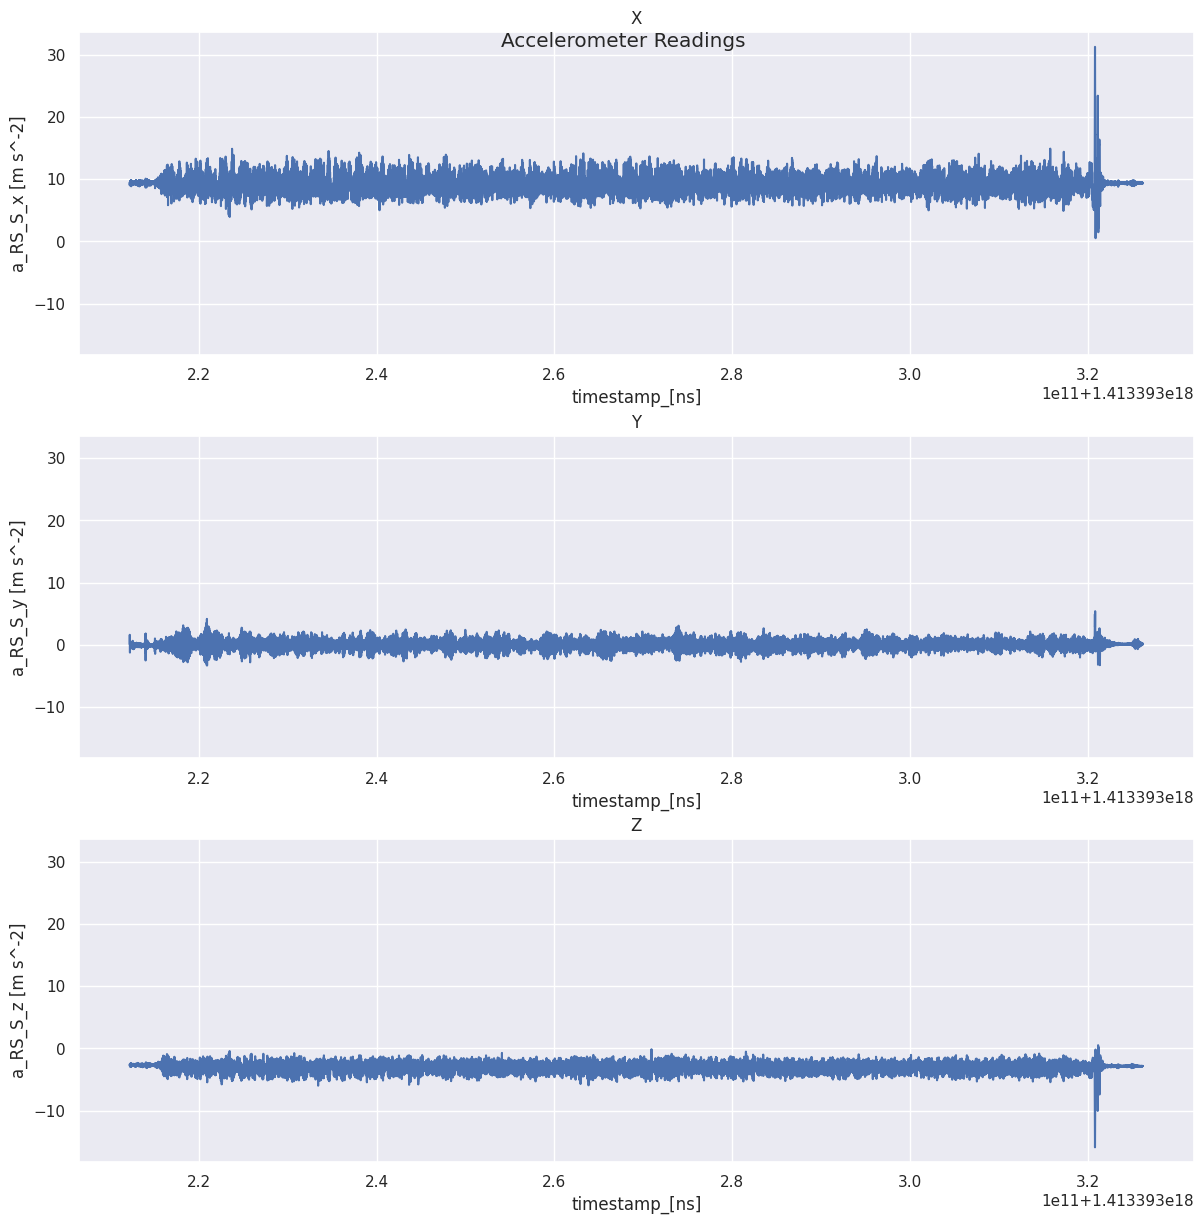

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)
fig.tight_layout()
plt.subplots_adjust(hspace=0.25)
fig.suptitle('Accelerometer Readings')

# Bulbasaur
sns.lineplot(ax=axes[0], x=df_imu[cols[0]], y=df_imu[cols[4]])
axes[0].set_title('X')

# Charmander
sns.lineplot(ax=axes[1], x=df_imu[cols[0]], y=df_imu[cols[5]])
axes[1].set_title('Y')

# Squirtle
sns.lineplot(ax=axes[2], x=df_imu[cols[0]], y=df_imu[cols[6]])
axes[2].set_title('Z')

### Investigating at specific time point

In [9]:
start_ts = 1413393322955760384
end_ts = 1413393326155760384

In [10]:
df_imu_filtered = df_imu.query(f"`{cols[0]}`>={start_ts} & `{cols[0]}`<={end_ts}")

In [11]:
df_imu_filtered.head(5)

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
22146,1413393322955760384,0.000698,0.027227,0.085870,9.438901,-0.081722,-2.876617
22147,1413393322960760576,0.004887,0.024435,0.082380,9.234595,0.122583,-2.786723
22148,1413393322965760512,0.010472,0.020944,0.070511,9.463417,0.130755,-2.876617
22149,1413393322970760448,0.009774,0.026529,0.074700,9.381695,0.106239,-2.835756
22150,1413393322975760384,-0.000698,0.020944,0.078889,9.259112,0.294199,-2.843929


In [12]:
df_imu_filtered.shape

(641, 7)

In [13]:
df_imu_filtered.describe()

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
count,6.410000e+02,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000
mean,1.413393e+18,-0.001987,0.023776,0.082020,9.363579,0.124648,-2.848964
std,9.259252e+08,0.014599,0.005852,0.005875,0.130390,0.197285,0.084042
min,1.413393e+18,-0.066323,-0.002094,0.053058,8.768780,-0.678293,-3.178989
25%,1.413393e+18,-0.005585,0.020246,0.078191,9.299973,0.065378,-2.892962
50%,1.413393e+18,-0.002094,0.023736,0.081681,9.373523,0.122583,-2.852101
75%,1.413393e+18,0.002094,0.027227,0.085172,9.438901,0.179789,-2.803067
max,1.413393e+18,0.057945,0.046077,0.105418,9.814822,0.956148,-2.484351


Text(0.5, 1.0, 'Z')

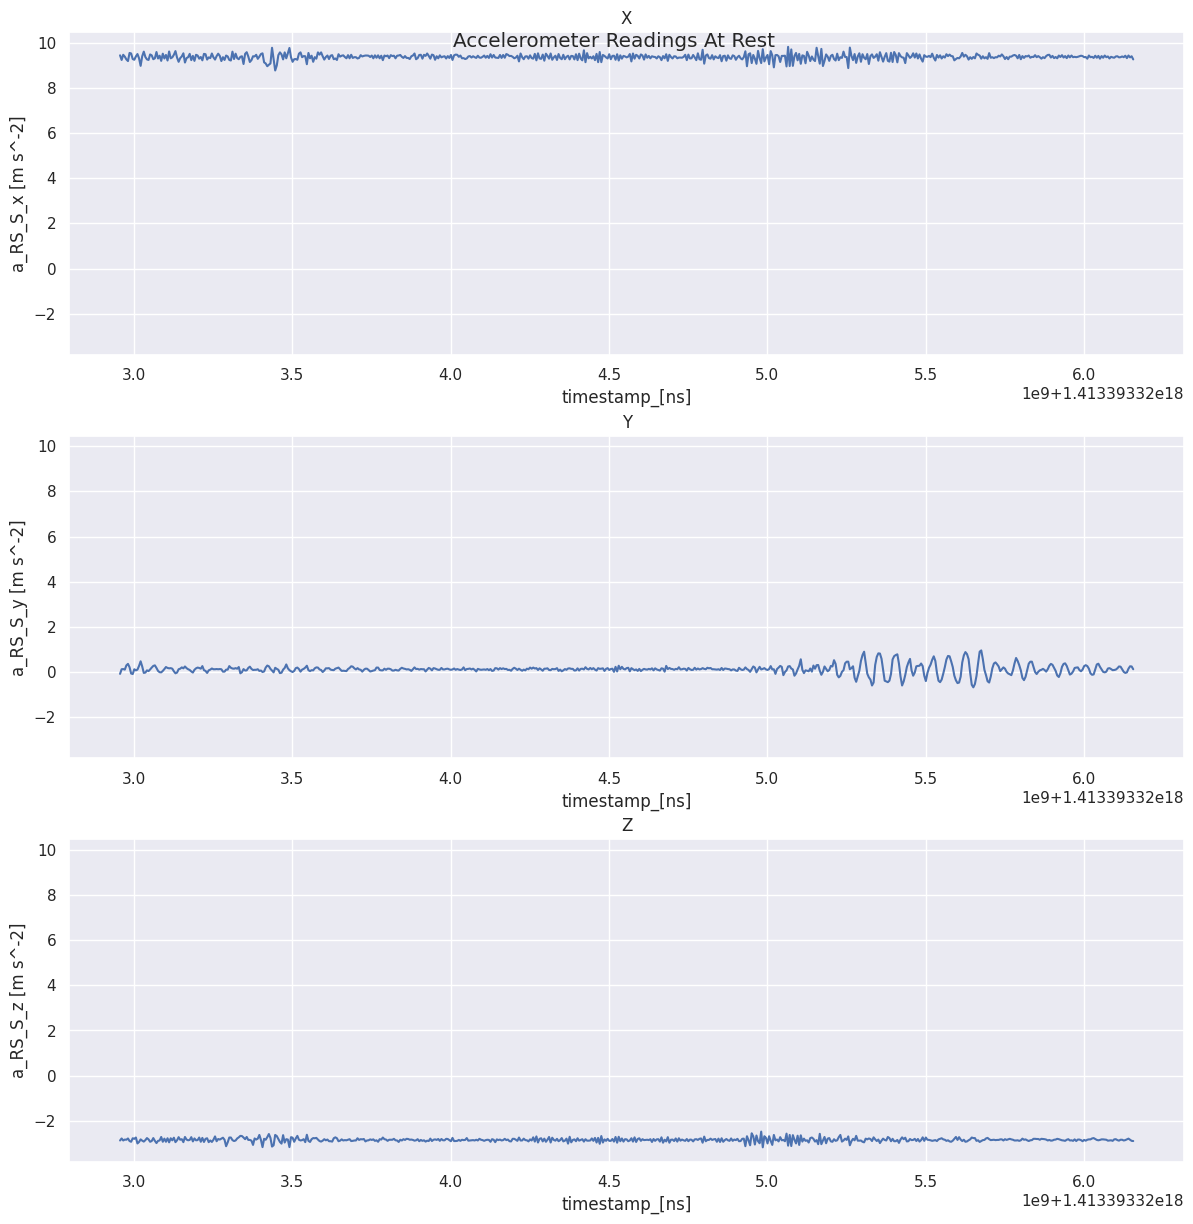

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)
fig.tight_layout()
plt.subplots_adjust(hspace=0.25)
fig.suptitle('Accelerometer Readings At Rest')

# Bulbasaur
sns.lineplot(ax=axes[0], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[4]])
axes[0].set_title('X')

# Charmander
sns.lineplot(ax=axes[1], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[5]])
axes[1].set_title('Y')

# Squirtle
sns.lineplot(ax=axes[2], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[6]])
axes[2].set_title('Z')

<Axes: xlabel='timestamp_[ns]', ylabel='w_RS_S_x [rad s^-1]'>

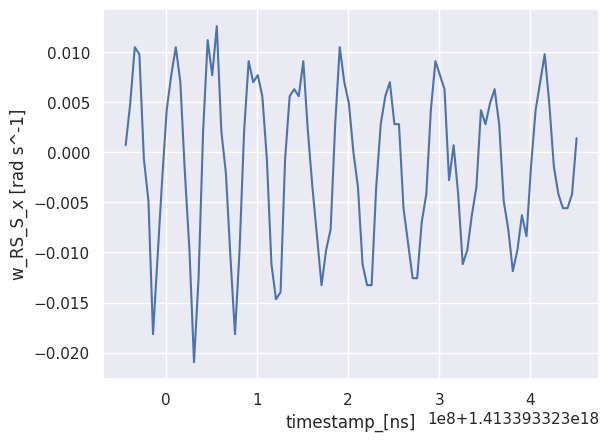

In [15]:
sns.lineplot(data = df_imu_filtered[0:100], x=cols[0], y=cols[1])